In [1]:
!pip install transformers
!pip install timm
!pip install torch torchvision
!pip install albumentations
!pip install opencv-python


In [4]:
!pip install -q transformers timm albumentations opencv-python tqdm


In [5]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)

# ==============================
# CONFIGURATION
# ==============================
RAW_DATASET = "/kaggle/input/pvforseg/PlantVillage"   # CHANGE if needed
SEGMENTED_DATASET = "/kaggle/working/PlantVillage_segmented"

CLASSES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

IMG_SIZE = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(SEGMENTED_DATASET, exist_ok=True)


In [6]:
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
)

segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
).to(DEVICE)

segformer_model.eval()
print("SegFormer-B2 loaded successfully")


/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


SegFormer-B2 loaded successfully


In [7]:
for cls in CLASSES:
    input_dir = os.path.join(RAW_DATASET, cls)
    output_dir = os.path.join(SEGMENTED_DATASET, cls)
    os.makedirs(output_dir, exist_ok=True)

    for img_name in tqdm(os.listdir(input_dir), desc=f"Segmenting {cls}"):
        img_path = os.path.join(input_dir, img_name)

        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue

        # BGR → RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Resize for SegFormer
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

        # Preprocess
        inputs = processor(images=img_resized, return_tensors="pt")
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        # Inference
        with torch.no_grad():
            outputs = segformer_model(**inputs)

        # -----------------------------
        # CRITICAL STEP: UPSAMPLE LOGITS
        # -----------------------------
        logits = outputs.logits
        logits = F.interpolate(
            logits,
            size=img_resized.shape[:2],
            mode="bilinear",
            align_corners=False
        )

        # Class prediction
        pred_mask = logits.argmax(dim=1)[0].cpu().numpy()

        # ADE20K: class 0 = background
        foreground_mask = (pred_mask != 0).astype(np.uint8) * 255

        # Convert mask to 3 channels
        foreground_mask_3ch = cv2.cvtColor(foreground_mask, cv2.COLOR_GRAY2BGR)

        # Apply mask
        segmented = cv2.bitwise_and(img_resized, foreground_mask_3ch)

        # Save
        save_path = os.path.join(output_dir, img_name)
        cv2.imwrite(save_path, cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))

print("Segmentation completed successfully")


Segmenting Potato___healthy: 100%|██████████| 1550/1550 [01:31<00:00, 16.93it/s]

Segmentation completed successfully


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 6441 files belonging to 3 classes.
Using 5153 files for training.


I0000 00:00:1768820098.636025      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14607 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 6441 files belonging to 3 classes.
Using 1288 files for validation.

================ TRAINING EfficientNetB0 =================
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Epoch 1/8


E0000 00:00:1768820113.045060      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768820120.596022     310 cuda_dnn.cc:529] Loaded cuDNN version 91002


162/162 ━━━━━━━━━━━━━━━━━━━━ 62s 205ms/step - accuracy: 0.7065 - loss: 0.6622 - val_accuracy: 0.9146 - val_loss: 0.2482
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9019 - loss: 0.2614 - val_accuracy: 0.9317 - val_loss: 0.1924
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9267 - loss: 0.2053 - val_accuracy: 0.9255 - val_loss: 0.1930
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9434 - loss: 0.1749 - val_accuracy: 0.9402 - val_loss: 0.1664
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9424 - loss: 0.1610 - val_accuracy: 0.9340 - val_loss: 0.1677
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9449 - loss: 0.1513 - val_accuracy: 0.9371 - val_loss: 0.1629
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9436 - loss: 0.1487 - val_accuracy: 0.9402 - val_loss: 0.1560
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9421 - loss: 0.1483 - val_accuracy: 0.9

E0000 00:00:1768820250.827564      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - accuracy: 0.9161 - loss: 0.2354 - val_accuracy: 0.9612 - val_loss: 0.1028 - learning_rate: 1.0000e-04
Epoch 2/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9570 - loss: 0.1141 - val_accuracy: 0.9658 - val_loss: 0.1013 - learning_rate: 1.0000e-04
Epoch 3/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9654 - loss: 0.0878 - val_accuracy: 0.9728 - val_loss: 0.0815 - learning_rate: 1.0000e-04
Epoch 4/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9705 - loss: 0.0811 - val_accuracy: 0.9674 - val_loss: 0.0939 - learning_rate: 1.0000e-04
Epoch 5/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9817 - loss: 0.0635 - val_accuracy: 0.9736 - val_loss: 0.0813 - learning_rate: 1.0000e-04
Epoch 6/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9869 - loss: 0.0404 - val_accuracy: 0.9752 - val_loss: 0.0915 - learning_rate: 1.0000e-04
Epoch 7/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accura

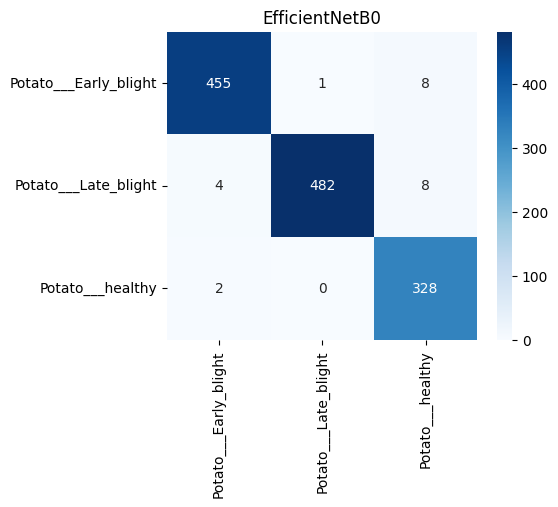


================ TRAINING EfficientNetV2B0 =================
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,019 (23.83 MB)

 Trainable params: 328,707 (1.25 MB)

...

Epoch 1/8


E0000 00:00:1768820452.130793      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


162/162 ━━━━━━━━━━━━━━━━━━━━ 36s 124ms/step - accuracy: 0.6957 - loss: 0.6827 - val_accuracy: 0.8998 - val_loss: 0.2850
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.8929 - loss: 0.2917 - val_accuracy: 0.9410 - val_loss: 0.1961
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9121 - loss: 0.2332 - val_accuracy: 0.9441 - val_loss: 0.1672
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9273 - loss: 0.1979 - val_accuracy: 0.9387 - val_loss: 0.1626
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9352 - loss: 0.1800 - val_accuracy: 0.9224 - val_loss: 0.1890
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9339 - loss: 0.1813 - val_accuracy: 0.9379 - val_loss: 0.1661
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9332 - loss: 0.1690 - val_accuracy: 0.9472 - val_loss: 0.1362
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9462 - loss: 0.1554 - val_accuracy: 0.9488 - v

E0000 00:00:1768820554.144053      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


162/162 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - accuracy: 0.9222 - loss: 0.2293 - val_accuracy: 0.9627 - val_loss: 0.1161 - learning_rate: 1.0000e-04
Epoch 2/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9471 - loss: 0.1443 - val_accuracy: 0.9550 - val_loss: 0.1177 - learning_rate: 1.0000e-04
Epoch 3/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9659 - loss: 0.1046 - val_accuracy: 0.9689 - val_loss: 0.0868 - learning_rate: 1.0000e-04
Epoch 4/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9671 - loss: 0.0841 - val_accuracy: 0.9635 - val_loss: 0.1086 - learning_rate: 1.0000e-04
Epoch 5/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9738 - loss: 0.0836 - val_accuracy: 0.9689 - val_loss: 0.0873 - learning_rate: 1.0000e-04
Epoch 6/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9770 - loss: 0.0687 - val_accuracy: 0.9705 - val_loss: 0.0863 - learning_rate: 1.0000e-05
Epoch 7/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accurac

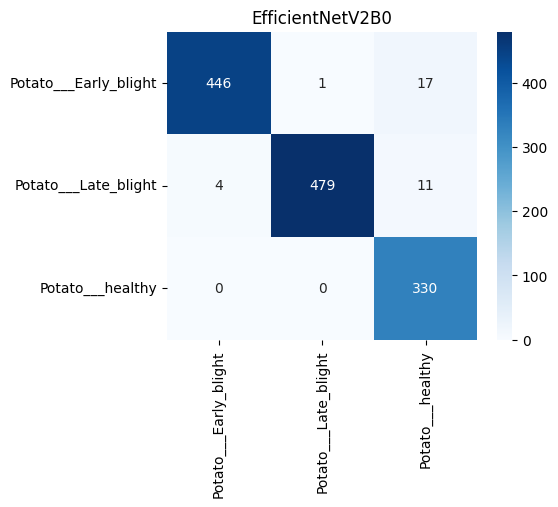


================ TRAINING ResNet50 =================
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[2][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[2][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[2][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        771 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 28s 122ms/step - accuracy: 0.7183 - loss: 0.7027 - val_accuracy: 0.9239 - val_loss: 0.2127
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9138 - loss: 0.2277 - val_accuracy: 0.9464 - val_loss: 0.1630
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9344 - loss: 0.1807 - val_accuracy: 0.9449 - val_loss: 0.1469
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9391 - loss: 0.1622 - val_accuracy: 0.9534 - val_loss: 0.1326
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9504 - loss: 0.1322 - val_accuracy: 0.9565 - val_loss: 0.1202
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.9529 - loss: 0.1335 - val_accuracy: 0.9488 - val_loss: 0.1521
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9553 - loss: 0.1247 - val_accuracy: 0.9573 - val_loss: 0.1162
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9599 - loss: 0.1129 - 

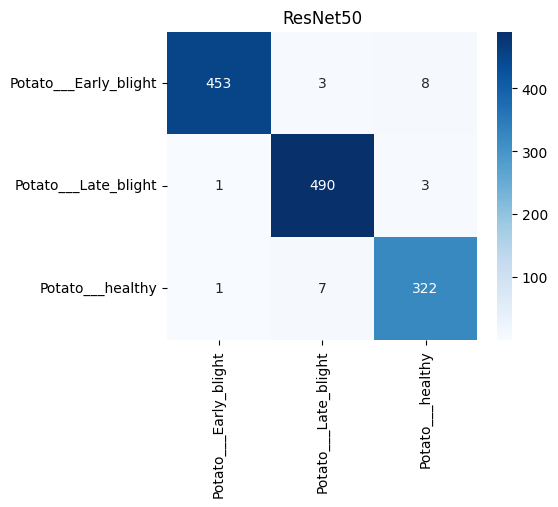


================ TRAINING MobileNetV3Large =================
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,139 (12.37 MB)

 Trainable params: 246,787 (964.01 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

Epoch 1/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - accuracy: 0.6553 - loss: 0.8129 - val_accuracy: 0.9293 - val_loss: 0.1982
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9046 - loss: 0.2374 - val_accuracy: 0.9542 - val_loss: 0.1333
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9388 - loss: 0.1671 - val_accuracy: 0.9557 - val_loss: 0.1216
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9511 - loss: 0.1324 - val_accuracy: 0.9620 - val_loss: 0.1104
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9534 - loss: 0.1279 - val_accuracy: 0.9596 - val_loss: 0.1123
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9682 - loss: 0.0926 - val_accuracy: 0.9596 - val_loss: 0.1090
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9633 - loss: 0.1037 - val_accuracy: 0.9682 - val_loss: 0.0902
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9637 - loss: 0.0958 - val_accuracy: 

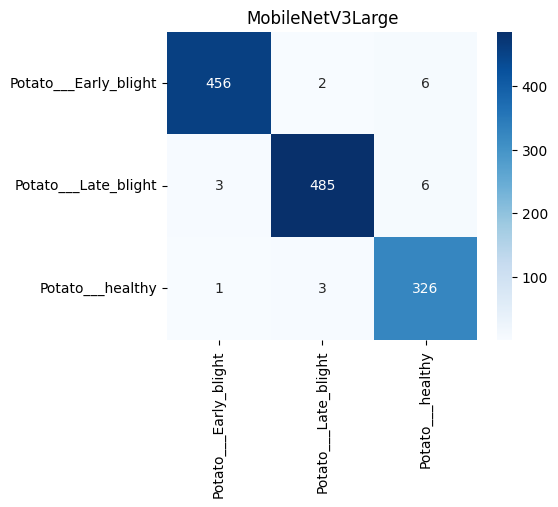


========== FINAL ACCURACY COMPARISON ==========
EfficientNetB0: 98.21%
EfficientNetV2B0: 97.44%
ResNet50: 98.21%
MobileNetV3Large: 98.37%


In [8]:
# =========================================================
# 0) GPU + MIXED PRECISION (SPEED BOOST)
# =========================================================
import tensorflow as tf
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")
print("GPU:", tf.config.list_physical_devices('GPU'))

# =========================================================
# 1) IMPORTS
# =========================================================
from tensorflow.keras.applications import (
    EfficientNetB0,
    EfficientNetV2B0,
    ResNet50,
    MobileNetV3Large
)
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effv2_pre
from tensorflow.keras.applications.resnet import preprocess_input as res_pre
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mob_pre

from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, Input
)
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# =========================================================
# 2) PATHS & PARAMETERS
# =========================================================
DATASET_DIR = "/kaggle/working/PlantVillage_segmented"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 8
EPOCHS_PHASE2 = 15
SEED = 42
NUM_CLASSES = 3

# =========================================================
# 3) DATA LOADING (FAST tf.data)
# =========================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# =========================================================
# 4) DATA AUGMENTATION
# =========================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

# =========================================================
# 5) MODEL FACTORY
# =========================================================
def build_model(base_model_fn, preprocess_fn):
    base_model = base_model_fn(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )
    base_model.trainable = False

    inputs = Input(shape=(224,224,3))
    x = data_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    return Model(inputs, outputs), base_model

# =========================================================
# 6) MODEL CONFIGURATIONS
# =========================================================
models_config = {
    "EfficientNetB0": (EfficientNetB0, eff_pre, 30),
    "EfficientNetV2B0": (EfficientNetV2B0, effv2_pre, 30),
    "ResNet50": (ResNet50, res_pre, 40),
    "MobileNetV3Large": (MobileNetV3Large, mob_pre, 20),
}

# =========================================================
# 7) TRAINING LOOP (ALL 4 MODELS)
# =========================================================
results = {}

for name, (model_fn, pre_fn, fine_layers) in models_config.items():
    print(f"\n================ TRAINING {name} =================")

    model, base_model = build_model(model_fn, pre_fn)
    model.summary()

    # -------- PHASE 1 --------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        ],
        verbose=1
    )

    # -------- PHASE 2 (FINE TUNE) --------
    base_model.trainable = True
    for layer in base_model.layers[:-fine_layers]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE2,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(patience=2)
        ],
        verbose=1
    )

    # -------- EVALUATION --------
    y_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)

    acc = np.mean(y_true == y_pred) * 100
    results[name] = acc

    print(f"\n{name} Validation Accuracy: {acc:.2f}%")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(name)
    plt.show()

# =========================================================
# 8) FINAL COMPARISON
# =========================================================
print("\n========== FINAL ACCURACY COMPARISON ==========")
for k, v in results.items():
    print(f"{k}: {v:.2f}%")
